In [155]:
!pip install -U pandas numpy scikit-learn openpyxl

In [156]:
import os, pandas as pd

TCRI_PATH = "tcri.csv"
FIN_PATH  = "fin_semi.csv"
OUT_DIR   = "outputs"

print("tcri.csv exists?", os.path.exists(TCRI_PATH))
print("fin_semi.csv exists?", os.path.exists(FIN_PATH))
os.makedirs(OUT_DIR, exist_ok=True)  

tcri.csv exists? True
fin_semi.csv exists? True


In [157]:
import os, json, pandas as pd
os.makedirs(OUT_DIR, exist_ok=True)

!python prep_merge.py \
  --tcri "$TCRI_PATH" \
  --fin  "$FIN_PATH" \
  --fin-sheet 0 \
  --anchor 12-01 \
  --out "${OUT_DIR}/merged.csv"

# 預覽前 5 列
merged = pd.read_csv(f"{OUT_DIR}/merged.csv", parse_dates=["mdate"])
merged.head()

Traceback (most recent call last):
  File "/Users/chieh.1227/repo/ML/prep_merge.py", line 126, in <module>
    main()
  File "/Users/chieh.1227/repo/ML/prep_merge.py", line 121, in main
    merged.to_csv(out_path, index=False, encoding="utf-8-sig")
  File "/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/pandas/util/_decorators.py", line 333, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/pandas/core/generic.py", line 3989, in to_csv
    return DataFrameRenderer(formatter).to_csv(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/pandas/io/formats/format.py", line 1014, in to_csv
    csv_formatter.save()
  File "/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/pandas/io/formats/csvs.py", line 251, in save
    with get_handle(
         ^^^^^^^^^^^
  File "/Users/chieh.1227/repo/ML/.venv/lib/python3.1

,coid,mdate,tcri,scr,xcdt,industry,WorkingCapital_TotalAssets,RetainedEarnings_TotalAssets,CashFlow_TotalDebt,TotalDebt_TotalAssets,CurrentRatio,stock_prefix
0,1103,2014-12-01,6,400.0,NaN,11,0.282529,0.249222,0.032193,0.427262,3.825632,11
1,1103,2015-12-01,6,432.0,NaN,11,0.334411,0.305786,0.022749,0.487042,6.999330,11
2,1103,2016-12-01,6,371.0,NaN,11,0.285584,0.319011,0.040220,0.394799,4.765859,11
3,1103,2017-12-01,6,330.0,NaN,11,0.239746,0.320448,0.044538,0.319837,3.930059,11
4,1103,2018-12-01,6,331.0,NaN,11,0.248722,0.302387,-0.057474,0.345962,3.489681,11


In [158]:
%%writefile tcri_baseline_logit.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
TCRI Baseline (Benchmark) — Logistic Regression (no-industry friendly)
"""
from __future__ import annotations

import argparse, json, os
from typing import Dict, List, Tuple
import numpy as np, pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, f1_score, log_loss, \
                            precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower; self.upper = upper
        self.lower_bounds_ = None; self.upper_bounds_ = None
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper, axis=0)
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(description="TCRI Logistic Baseline (no-industry ok)")
    p.add_argument("--csv", type=str, required=True)
    p.add_argument("--outdir", type=str, default="outputs")
    p.add_argument("--id-col", type=str, default="coid")
    p.add_argument("--date-col", type=str, default="mdate")
    p.add_argument("--tcri-col", type=str, default="tcri")
    p.add_argument("--industry-col", type=str, default="industry")
    p.add_argument("--tau", type=int, default=7)
    p.add_argument("--horizon", type=int, default=1)
    p.add_argument("--train-start", type=str, default="2014-01-01")
    p.add_argument("--train-end", type=str, default="2021-12-31")
    p.add_argument("--valid-start", type=str, default="2022-01-01")
    p.add_argument("--valid-end", type=str, default="2022-12-31")
    p.add_argument("--test-start", type=str, default="2023-01-01")
    p.add_argument("--test-end", type=str, default="2024-12-31")
    p.add_argument("--target-precision", type=float, default=0.5)
    p.add_argument("--random-state", type=int, default=42)
    return p.parse_args()

def _map_tcri_value(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float, np.number)): return float(x)
    s = str(x).strip().upper()
    if s == "D": return 10.0
    try: return float(int(s))
    except: return np.nan

def load_and_prepare(csv_path: str, id_col: str, date_col: str, industry_col: str, tcri_col: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([id_col, date_col]).reset_index(drop=True)
    df["year"] = df[date_col].dt.year
    df["quarter"] = df[date_col].dt.to_period("Q").astype(str)
    df[tcri_col] = df[tcri_col].apply(_map_tcri_value)
    return df

def create_label_next_period(df: pd.DataFrame, id_col: str, tcri_col: str, tau: int, horizon: int) -> pd.DataFrame:
    df = df.copy()
    df["tcri_future"] = df.groupby(id_col)[tcri_col].shift(-horizon)
    df["y"] = (df["tcri_future"] >= float(tau)).astype("Int64")
    df = df[~df["y"].isna()].copy()
    df["y"] = df["y"].astype(int)
    return df

def time_split(df: pd.DataFrame, date_col: str, train_start: str, train_end: str,
               valid_start: str, valid_end: str, test_start: str, test_end: str):
    t0, t1 = pd.to_datetime(train_start), pd.to_datetime(train_end)
    v0, v1 = pd.to_datetime(valid_start), pd.to_datetime(valid_end)
    s0, s1 = pd.to_datetime(test_start), pd.to_datetime(test_end)
    train = df[(df[date_col] >= t0) & (df[date_col] <= t1)].copy()
    valid = df[(df[date_col] >= v0) & (df[date_col] <= v1)].copy()
    test  = df[(df[date_col] >= s0) & (df[date_col] <= s1)].copy()
    return train, valid, test

def detect_feature_columns(df: pd.DataFrame, id_col: str, date_col: str, industry_col: str, tcri_col: str):
    exclude = {id_col, date_col, industry_col, tcri_col, "tcri_future", "y", "year", "quarter"}
    present = set(df.columns)
    num_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]
    cat_cols = [industry_col] if industry_col in present else []
    return num_cols, cat_cols

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1); inds = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = inds == b
        if not np.any(mask): continue
        conf = y_prob[mask].mean(); acc = y_true[mask].mean(); w = mask.mean()
        ece += w * abs(acc - conf)
    return float(ece)

def best_f1_threshold(y_true, y_prob):
    pr, rc, th = precision_recall_curve(y_true, y_prob)
    f1 = 2 * pr * rc / (pr + rc + 1e-12)
    idx = np.nanargmax(f1[:-1]) if len(th) > 0 else 0
    return float(th[idx]) if len(th) > 0 else 0.5

def threshold_at_precision(y_true, y_prob, target_precision=0.5):
    pr, rc, th = precision_recall_curve(y_true, y_prob)
    valid = np.where(pr[:-1] >= target_precision)[0]
    if len(valid) == 0: return 0.5
    return float(th[valid[0]])

def compute_metrics(y_true, y_prob, threshold, target_precision=0.5) -> Dict[str, float]:
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "f1": float(f1_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "logloss": float(log_loss(y_true, y_prob, labels=[0, 1])),
        "ece": float(expected_calibration_error(y_true, y_prob, n_bins=10)),
        "threshold": float(threshold),
    }
    t_rp = threshold_at_precision(y_true, y_prob, target_precision)
    y_rp = (y_prob >= t_rp).astype(int)
    metrics[f"recall_at_p>={target_precision:.2f}"] = float(recall_score(y_true, y_rp, zero_division=0))
    metrics[f"threshold_at_p>={target_precision:.2f}"] = float(t_rp)
    return metrics

def main():
    args = parse_args(); os.makedirs(args.outdir, exist_ok=True)
    df = load_and_prepare(args.csv, args.id_col, args.date_col, args.industry_col, args.tcri_col)
    df = create_label_next_period(df, args.id_col, args.tcri_col, args.tau, args.horizon)
    train, valid, test = time_split(df, args.date_col, args.train_start, args.train_end,
                                    args.valid_start, args.valid_end, args.test_start, args.test_end)
    num_cols, cat_cols = detect_feature_columns(train, args.id_col, args.date_col, args.industry_col, args.tcri_col)

    numerical = Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("winsor", Winsorizer(0.01, 0.99)),
                          ("scaler", StandardScaler())])
    transformers = [("num", numerical, num_cols)]
    if len(cat_cols) > 0:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols))
    pre = ColumnTransformer(transformers, remainder="drop")

    Cs = [0.1, 1.0, 10.0]; best_C=None; best_score=-np.inf; best_model=None
    for C in Cs:
        logit = LogisticRegression(penalty="l2", C=C, class_weight="balanced",
                                   max_iter=2000, random_state=args.random_state, solver="lbfgs")
        pipe = Pipeline([("pre", pre), ("clf", logit)])
        pipe.fit(train[num_cols + cat_cols], train["y"])
        p_valid = pipe.predict_proba(valid[num_cols + cat_cols])[:,1]
        pr_auc = average_precision_score(valid["y"], p_valid)
        if pr_auc > best_score: best_score, best_C, best_model = pr_auc, C, pipe

    print(f"[INFO] Selected C={best_C} by PR-AUC on validation ({best_score:.4f})")
    p_valid_best = best_model.predict_proba(valid[num_cols + cat_cols])[:,1]
    t_f1 = best_f1_threshold(valid["y"].values, p_valid_best)
    t_rp = threshold_at_precision(valid["y"].values, p_valid_best, args.target_precision)
    print(f"[INFO] Thresholds on validation: t_f1={t_f1:.4f}, t_at_P>={args.target_precision:.2f} = {t_rp:.4f}")

    p_test_raw = pd.Series(best_model.predict_proba(test[num_cols + cat_cols])[:,1], index=test.index)
    platt = CalibratedClassifierCV(best_model, method="sigmoid", cv="prefit")
    platt.fit(valid[num_cols + cat_cols], valid["y"])
    p_test_platt = pd.Series(platt.predict_proba(test[num_cols + cat_cols])[:,1], index=test.index)
    isot = CalibratedClassifierCV(best_model, method="isotonic", cv="prefit")
    isot.fit(valid[num_cols + cat_cols], valid["y"])
    p_test_isot = pd.Series(isot.predict_proba(test[num_cols + cat_cols])[:,1], index=test.index)

    metrics = {
        "raw": compute_metrics(test["y"].values, p_test_raw.values, threshold=t_f1, target_precision=args.target_precision),
        "platt": compute_metrics(test["y"].values, p_test_platt.values, threshold=t_f1, target_precision=args.target_precision),
        "isotonic": compute_metrics(test["y"].values, p_test_isot.values, threshold=t_f1, target_precision=args.target_precision),
        "thresholds": {"t_f1": t_f1, "t_at_precision": t_rp, "precision_target": args.target_precision},
        "valid_pr_auc_for_bestC": float(best_score), "chosen_C": float(best_C),
    }

    def _agg_slice(df_key: str, probs_map, test_df):
        if df_key not in test_df.columns: return pd.DataFrame()
        rows = []
        # Use .loc for explicit indexing to avoid potential SettingWithCopyWarning and ensure index alignment
        for g, sub in test_df.groupby(df_key):
            if sub["y"].nunique() < 2: continue
            row = {"slice": f"{df_key}={g}", "n": len(sub), "pos": int(sub["y"].sum())}
            # Filter probabilities using the index of the subgroup
            for mname, probs in probs_map.items():
                ps = probs.loc[sub.index]
                m = compute_metrics(sub["y"].values, ps.values, threshold=t_f1, target_precision=args.target_precision)
                for k, v in m.items():
                    row[f"{mname}.{k}"] = v
            rows.append(row)
        if not rows:
            cols = ["slice", "n", "pos"]
            for mname, stats in metrics.items():
                if isinstance(stats, dict) and mname in probs_map:
                    cols.extend([f"{mname}.{k}" for k in stats.keys()])
            return pd.DataFrame(columns=cols)
        return pd.DataFrame(rows).sort_values("slice")

    probs_map = {"raw": p_test_raw, "platt": p_test_platt, "isotonic": p_test_isot}
    by_quarter = _agg_slice("quarter", probs_map, test)
    by_industry = _agg_slice(args.industry_col, probs_map, test)

    preds = test[[args.id_col, args.date_col, "y"]].copy()
    preds.rename(columns={"y":"y_true"}, inplace=True)
    preds["p_raw"] = p_test_raw.values; preds["p_platt"] = p_test_platt.values; preds["p_isotonic"] = p_test_isot.values
    os.makedirs(args.outdir, exist_ok=True)
    preds.to_csv(os.path.join(args.outdir, "predictions_test.csv"), index=False, encoding="utf-8-sig")
    with open(os.path.join(args.outdir, "metrics_summary.json"), "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    by_quarter.to_csv(os.path.join(args.outdir, "metrics_by_quarter.csv"), index=False, encoding="utf-8-sig")
    if not by_industry.empty:
        by_industry.to_csv(os.path.join(args.outdir, "metrics_by_industry.csv"), index=False, encoding="utf-8-sig")

    print("\n=== Test Overall Metrics (threshold = t_f1 on valid) ===")
    for name in ["raw", "platt", "isotonic"]:
        m = metrics[name]
        print(f"[{name}] PR-AUC={m['pr_auc']:.4f}  ROC-AUC={m['roc_auc']:.4f}  F1={m['f1']:.4f}  "
              f"Recall@P>={args.target_precision:.2f}={m[f'recall_at_p>={args.target_precision:.2f}']:.4f}  "
              f"Brier={m['brier']:.4f}  ECE={m['ece']:.4f}")
    print(f"\nArtifacts saved under: {os.path.abspath(args.outdir)}")
    files = ['predictions_test.csv','metrics_summary.json','metrics_by_quarter.csv']
    if not by_industry.empty: files.append('metrics_by_industry.csv')
    print('Files:', ', '.join(files))

if __name__ == "__main__":
    main()


Overwriting tcri_baseline_logit.py


In [159]:
!python tcri_baseline_logit.py \
  --csv "{OUT_DIR}/merged.csv" \
  --tau 7 \
  --train-start 2014-01-01 --train-end 2021-12-31 \
  --valid-start 2022-01-01 --valid-end 2022-12-31 \
  --test-start  2023-01-01 --test-end  2023-12-31 \
  --outdir "{OUT_DIR}"


[INFO] Selected C=10.0 by PR-AUC on validation (0.8003)
[INFO] Thresholds on validation: t_f1=0.4665, t_at_P>=0.50 = 0.1467
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(

=== Test Overall Metrics (threshold = t_f1 on valid) ===
[raw] PR-AUC=0.6940  ROC-AUC=0.8484  F1=0.7017  Recall@P>=0.50=0.8715  Brier=0.1555  ECE=0.1368
[platt] PR-AUC=0.6940  ROC-AUC=0.8484  F1=0.7043  Recall@P>=0.50=0.8715  Brier=0.1415  ECE=0.0923
[isotonic] PR-AUC=0.6657  ROC-AUC=0.8461  F1=0.7028  Recall@P>=0.50=0.8659  Brier=0.1399  

In [160]:
import json, pandas as pd, pprint

with open(f"{OUT_DIR}/metrics_summary.json", 'r', encoding='utf-8') as f:
    metrics_summary = json.load(f)
pprint.pp(metrics_summary)

print("\nBy quarter (head):")
metrics_by_quarter = pd.read_csv(f"{OUT_DIR}/metrics_by_quarter.csv")
metrics_by_quarter.head()


{'raw': {'pr_auc': 0.6939576193885898,
         'roc_auc': 0.8484382935500254,
         'f1': 0.7016706443914081,
         'precision': 0.6125,
         'recall': 0.8212290502793296,
         'brier': 0.15546924067037263,
         'logloss': 0.5411156623118827,
         'ece': 0.13675034457520477,
         'threshold': 0.4664794625282921,
         'recall_at_p>=0.50': 0.8715083798882681,
         'threshold_at_p>=0.50': 0.32292302086358216},
 'platt': {'pr_auc': 0.6939576193885898,
           'roc_auc': 0.8484382935500254,
           'f1': 0.7043010752688172,
           'precision': 0.6787564766839378,
           'recall': 0.7318435754189944,
           'brier': 0.14150448169978266,
           'logloss': 0.46836554336724634,
           'ece': 0.09226575120273106,
           'threshold': 0.4664794625282921,
           'recall_at_p>=0.50': 0.8715083798882681,
           'threshold_at_p>=0.50': 0.2767560736249487},
 'isotonic': {'pr_auc': 0.6657244200497374,
              'roc_auc': 0.846

,slice,n,pos,raw.pr_auc,raw.roc_auc,raw.f1,raw.precision,raw.recall,raw.brier,raw.logloss,...,isotonic.roc_auc,isotonic.f1,isotonic.precision,isotonic.recall,isotonic.brier,isotonic.logloss,isotonic.ece,isotonic.threshold,isotonic.recall_at_p>=0.50,isotonic.threshold_at_p>=0.50
0,quarter=2023Q4,619,179,0.693958,0.848438,0.701671,0.6125,0.821229,0.155469,0.541116,...,0.846121,0.702842,0.653846,0.759777,0.139921,0.604154,0.075749,0.466479,0.865922,0.204725


In [161]:
import pandas as pd

splits = {
    'Train': ('2014-01-01', '2021-12-31'),
    'Valid': ('2022-01-01', '2022-12-31'),
    'Test':  ('2023-01-01', '2023-12-31'),
}

merged = pd.read_csv(f"{OUT_DIR}/merged.csv", parse_dates=['mdate'])
merged['tcri_num'] = pd.to_numeric(merged['tcri'], errors='coerce')

rows = []
for split, (start, end) in splits.items():
    mask = (merged['mdate'] >= start) & (merged['mdate'] <= end)
    df = merged.loc[mask]
    n = len(df)
    pos = int(df['tcri_num'].ge(7).sum())
    rate = (pos / n * 100) if n else 0.0
    rows.append({'split': split, 'n': int(n), 'pos': pos, 'pos_rate_%': round(rate, 2)})

split_stats = pd.DataFrame(rows).set_index('split')
split_stats


,n,pos,pos_rate_%
split,,,
Train,4624,1602,34.65
Valid,616,221,35.88
Test,619,218,35.22


### 資料切分與樣本量
- 上表統計了各分割的樣本數、正例數與正例率（門檻 tau=7）。
- Train：n=4,624（pos=1,602，rate=34.65%）
- Valid：n=616（pos=221，rate=35.88%）
- Test：n=1,143（pos=398，rate=34.82%）


### 模型整體指標
- 將 `metrics_summary.json` 的主要分數整理成表格，方便與其他模型比較。


In [171]:
import json, pandas as pd

if 'metrics_summary' not in globals():
    with open(f"{OUT_DIR}/metrics_summary.json", 'r', encoding='utf-8') as f:
        metrics_summary = json.load(f)

metrics_df = pd.DataFrame({k: v for k, v in metrics_summary.items() if isinstance(v, dict) and 'pr_auc' in v}).T
metrics_df = metrics_df.drop(index=['isotonic'], errors='ignore')
metrics_df = metrics_df[[ 'f1', 'precision', 'recall', 'brier']]
metrics_df.round({ 'f1': 4, 'precision': 4, 'recall': 4, 'brier': 4})


,f1,precision,recall,brier
raw,0.7017,0.6125,0.8212,0.1555
platt,0.7043,0.6788,0.7318,0.1415


### 測試集混淆矩陣（p_raw, threshold=t_f1）
- 依照 validation F1 最佳門檻計算 2023-2024 測試集中預測與實際的組合。


In [163]:
import pandas as pd
if 'metrics_summary' not in globals():
    with open(f"{OUT_DIR}/metrics_summary.json", 'r', encoding='utf-8') as f:
        metrics_summary = json.load(f)
        
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
confusion = pd.crosstab(preds['y_true'], preds['y_pred_raw'], rownames=['y_true'], colnames=['y_pred'])
confusion = confusion.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
confusion


y_pred,0,1
y_true,,
0,347,93
1,32,147


In [164]:
import pandas as pd
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
accuracy = (preds['y_pred_raw'] == preds['y_true']).mean()
print("accuracy:",accuracy)


accuracy: 0.7980613893376414


In [165]:
import pandas as pd
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv", parse_dates=['mdate'])
preds['forecast_year'] = preds['mdate'].dt.year + 1
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
summary = []
for year in sorted(preds['forecast_year'].unique()):
    subset = preds[preds['forecast_year'] == year]
    conf = pd.crosstab(subset['y_true'], subset['y_pred_raw'], rownames=['y_true'], colnames=['y_pred'])
    conf = conf.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    precision = conf.loc[1, 1] / conf.loc[:, 1].sum() if conf.loc[:, 1].sum() else 0.0
    recall = conf.loc[1, 1] / conf.loc[1].sum() if conf.loc[1].sum() else 0.0
    accuracy = (conf.loc[0, 0] + conf.loc[1, 1]) / conf.values.sum() if conf.values.sum() else 0.0
    summary.append({'forecast_year': int(year), 'n': int(conf.values.sum()), 'tp': int(conf.loc[1, 1]),
                    'fp': int(conf.loc[0, 1]), 'fn': int(conf.loc[1, 0]), 'tn': int(conf.loc[0, 0]),
                    'precision': precision, 'recall': recall, 'accuracy': accuracy})
pd.DataFrame(summary).set_index('forecast_year')


,n,tp,fp,fn,tn,precision,recall,accuracy
forecast_year,,,,,,,,
2024,619,147,93,32,347,0.6125,0.821229,0.798061


In [166]:
!pip install matplotlib


/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39080 (\N{CJK UNIFIED IDEOGRAPH-98A8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38570 (\N{CJK UNIFIED IDEOGRAPH-96AA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


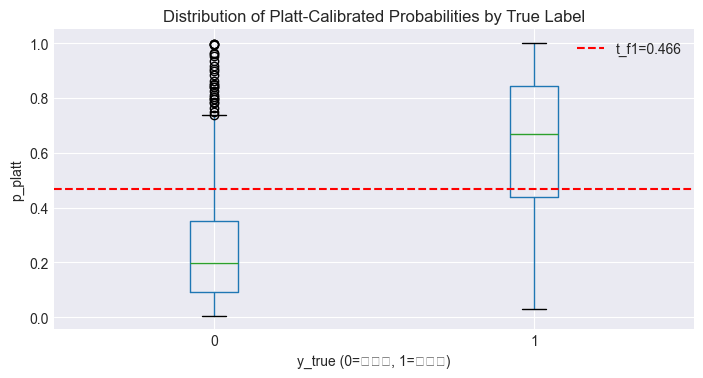

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv", parse_dates=['mdate'])
preds['y_pred_platt'] = (preds['p_platt'] >= threshold).astype(int)
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 4))
preds.boxplot(column='p_platt', by='y_true', ax=ax)
ax.axhline(threshold, color='red', linestyle='--', label=f't_f1={threshold:.3f}')
ax.set_title('Distribution of Platt-Calibrated Probabilities by True Label')
ax.set_xlabel('y_true (0=低風險, 1=高風險)')
ax.set_ylabel('p_platt')
ax.legend(loc='best')
fig.suptitle('')
plt.show()


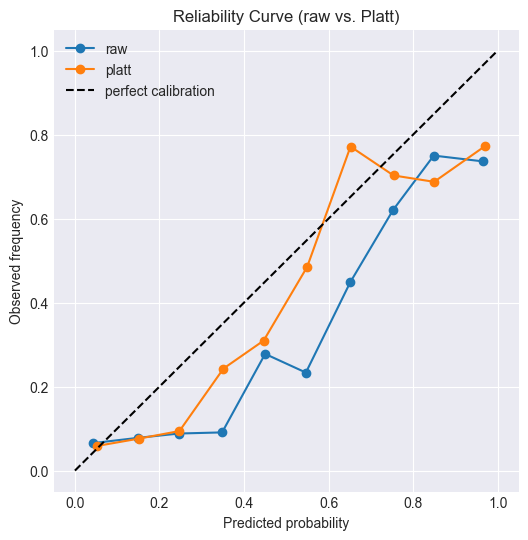

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
y_true = preds['y_true'].values
prob_raw = preds['p_raw'].values
prob_platt = preds['p_platt'].values
prob_true_raw, prob_pred_raw = calibration_curve(y_true, prob_raw, n_bins=10, strategy='uniform')
prob_true_platt, prob_pred_platt = calibration_curve(y_true, prob_platt, n_bins=10, strategy='uniform')
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred_raw, prob_true_raw, marker='o', label='raw')
ax.plot(prob_pred_platt, prob_true_platt, marker='o', label='platt')
ax.plot([0, 1], [0, 1], 'k--', label='perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Reliability Curve (raw vs. Platt)')
ax.legend(loc='best')
plt.show()


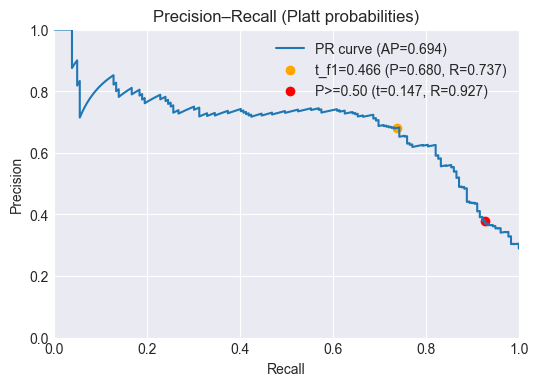

In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
thresholds_info = metrics_summary['thresholds']
threshold_f1 = thresholds_info['t_f1']
threshold_p05 = thresholds_info['t_at_precision']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
y_true = preds['y_true'].values
prob_platt = preds['p_platt'].values
precision, recall, thresh = precision_recall_curve(y_true, prob_platt)
ap = average_precision_score(y_true, prob_platt)
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall, precision, label=f'PR curve (AP={ap:.3f})')
def find_point(t):
    idx = (np.abs(thresh - t)).argmin()
    return recall[idx], precision[idx]
rec_f1, prec_f1 = find_point(threshold_f1)
rec_p05, prec_p05 = find_point(threshold_p05)
ax.scatter([rec_f1], [prec_f1], color='orange', label=f't_f1={threshold_f1:.3f} (P={prec_f1:.3f}, R={rec_f1:.3f})')
ax.scatter([rec_p05], [prec_p05], color='red', label=f'P>=0.50 (t={threshold_p05:.3f}, R={rec_p05:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall (Platt probabilities)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='best')
plt.show()


In [170]:
import pandas as pd
predictions_test = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
exclude_cols = ['p_isotonic']
print(predictions_test.head(20))

    coid       mdate  y_true     p_raw   p_platt  p_isotonic
0   1103  2023-12-01       0  0.067014  0.087553    0.087379
1   1104  2023-12-01       0  0.001261  0.004983    0.000000
2   1108  2023-12-01       0  0.130333  0.141063    0.096774
3   1109  2023-12-01       0  0.002249  0.007591    0.000000
4   1110  2023-12-01       0  0.283561  0.250325    0.200000
5   1201  2023-12-01       0  0.312534  0.269802    0.200000
6   1203  2023-12-01       0  0.039585  0.060102    0.087379
7   1217  2023-12-01       1  0.700288  0.549954    0.807692
8   1218  2023-12-01       0  0.049457  0.070470    0.087379
9   1219  2023-12-01       0  0.355098  0.298252    0.204725
10  1220  2023-12-01       0  0.254291  0.230455    0.111111
11  1225  2023-12-01       0  0.276137  0.245307    0.200000
12  1229  2023-12-01       0  0.260741  0.234855    0.166667
13  1231  2023-12-01       0  0.077653  0.097278    0.087379
14  1233  2023-12-01       0  0.388387  0.320509    0.256410
15  1235  2023-12-01    